In [12]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import json
import pickle
import time
from urllib.request import urlopen

import networkx as nx
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import plotly.express as px
from tqdm import tqdm
import reverse_geocoder as rg


In [13]:

YEAR = "2020"
TARGET_TOPIC = "worried"
EXCEL_PATH = "YCOM_2024_publicdata.xlsx"
GOWALLA_CHECKINS = "gowalla_data/Gowalla_totalCheckins.txt"
GOWALLA_CSV = "gowalla_data/gowalla_total.csv"
GOWALLA_EDGES = "gowalla_data/Gowalla_edges.txt"
FILTERED_EDGE_LIST = "gowalla_data/filtered_edge_list.txt"
NETWORK_GRAPH_DIR = "network_graphs"
RESULTS_DIR = "fj_model_results"
VIZ_DIR = "fixed_fj_visualizations"

In [ ]:
def plot_choropleth(G, nodes, x_baseline, x_final, year):

    # FIX: opinions are already on the [-1, 1] net-opinion scale, so delta is
    # directly interpretable — do NOT divide by 100 again (that was the bug
    # causing all plots to look identical, compressing deltas to ~0.0002).
    delta_x = x_final - x_baseline

    data = [
        {
            "County": G.nodes[node].get("county", ""),
            "State": G.nodes[node].get("state", ""),
            "Opinion_Delta": delta_x[i],
        }
        for i, node in enumerate(nodes)
    ]
    df_raw = pd.DataFrame(data)
    df_county = (
        df_raw.groupby(["State", "County"])["Opinion_Delta"]
        .mean()
        .reset_index()
        .sort_values(by="Opinion_Delta", ascending=False)
    )
    df_county.to_csv(f"fixed_fj_visualizations/county_delta_{year}.csv")
    # FIPS lookup — filter to one row per county to avoid duplicates from the
    # worried/worriedOppose row structure in YCOM_2010_2024
    yale_lookup = pd.read_excel(EXCEL_PATH, sheet_name="YCOM_2010_2024")
    yale_lookup = yale_lookup[
        (yale_lookup["GeoType"] == "county") &
        (yale_lookup["worried"] == TARGET_TOPIC)
    ].copy()
    yale_lookup[["County", "State"]] = yale_lookup["GeoName"].str.split(",", expand=True)
    yale_lookup["County"] = yale_lookup["County"].str.strip()
    yale_lookup["State"] = yale_lookup["State"].str.strip()

    df_county = df_county.merge(
        yale_lookup[["County", "State", "GeoID"]], on=["County", "State"], how="left"
    )
    df_county = df_county.dropna(subset=["GeoID"])
    df_county["FIPS"] = df_county["GeoID"].astype(int).astype(str).str.zfill(5)
    df_county = df_county.drop(columns=["GeoID"])

    with urlopen(
        "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
    ) as response:
        counties_geojson = json.load(response)

    fig = px.choropleth(
        df_county,
        geojson=counties_geojson,
        locations="FIPS",
        color="Opinion_Delta",
        color_continuous_scale="Blues",
        range_color=[0, 0.5],
        scope="usa",
        hover_name="County",
        hover_data=["State", "Opinion_Delta"],
        title=f"Change in Opinion after Seeding — {year}",
    )
    fig.update_layout(margin={"r": 0, "t": 40, "l": 0, "b": 0})
    # just save the html instead
    fig.write_html(os.path.join(VIZ_DIR, f"{year}_choropleth.html"))
    # fig.write_image(os.path.join(VIZ_DIR, f"change_opinion_{year}.png"))


In [21]:
def load_graph_and_matrices(filepath):
    print("Loading graph...")
    with open(filepath, 'rb') as f:
        G = pickle.load(f)

    nodes = list(G.nodes())
    return G, nodes

In [22]:

def plot_distribution_shift(x_baseline, x_final, year):
    plt.figure()

    plt.hist(x_final, bins=50, alpha=0.5, label="After Seeding")
    plt.hist(x_baseline, bins=50, alpha=0.5, label="Baseline")

    plt.xlabel("Opinion Value")
    plt.ylabel("Number of Users")
    plt.title(f"Opinion Distribution Shift - {year}")
    plt.xlim([-0.2, 1.0])
    plt.ylim([0, 6000])
    plt.legend()
    plt.savefig(f"fixed_fj_visualizations/{year}_opinion_distribution_shift.png")
    plt.show()

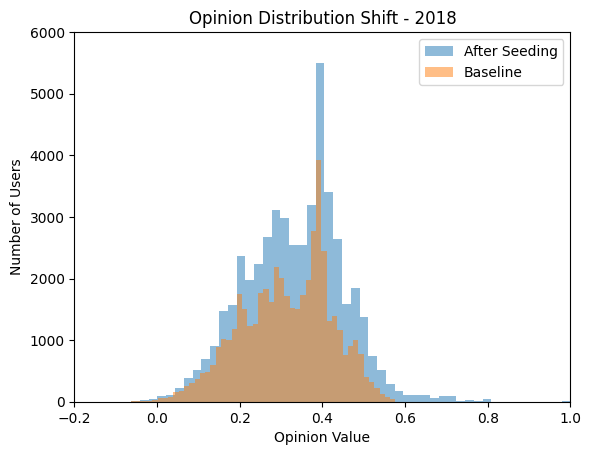

Loading graph...


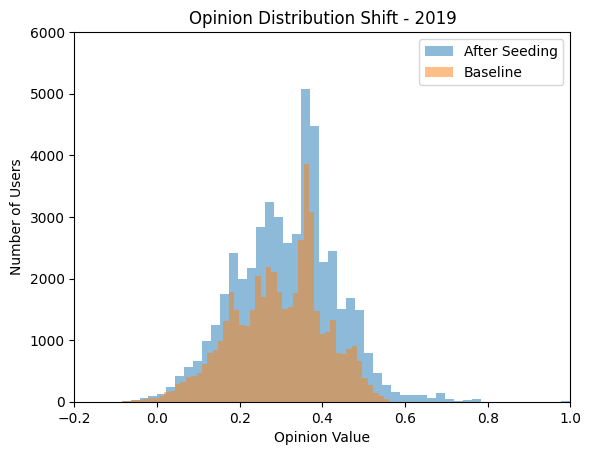

Loading graph...


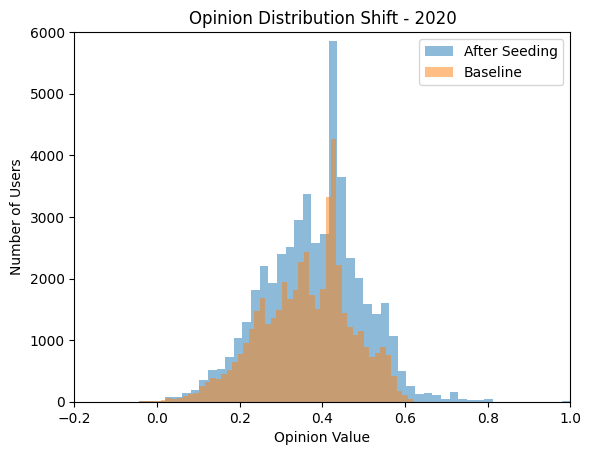

Loading graph...


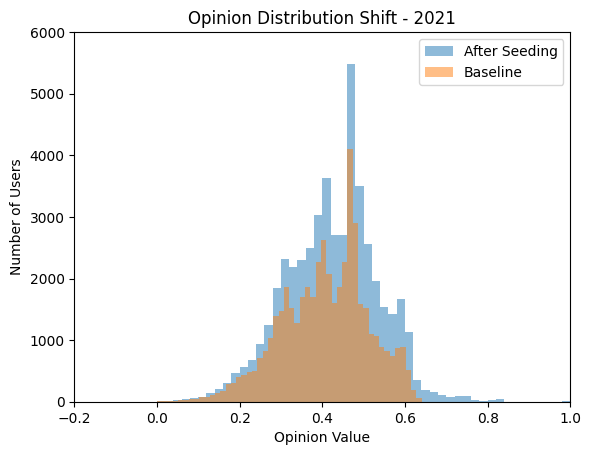

Loading graph...


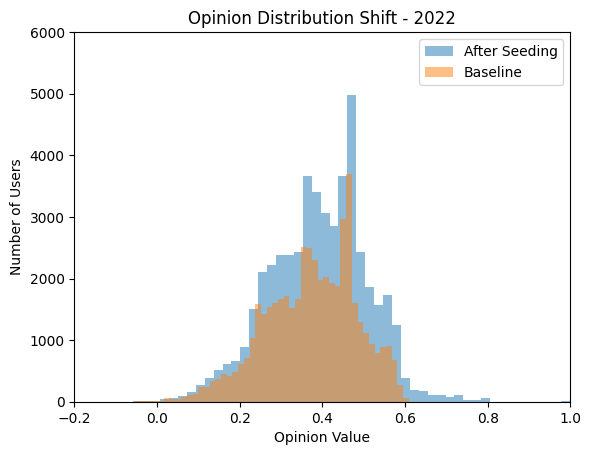

Loading graph...


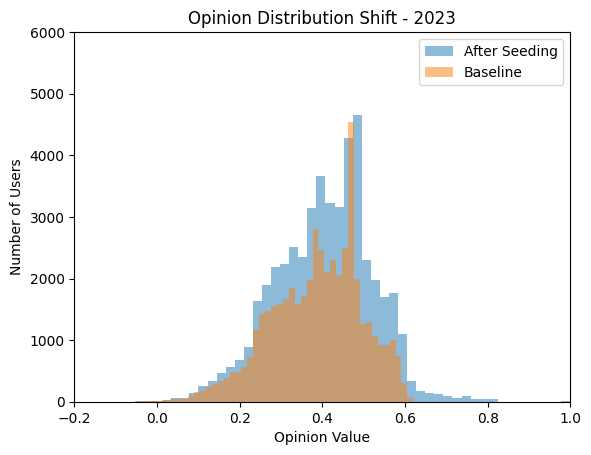

Loading graph...


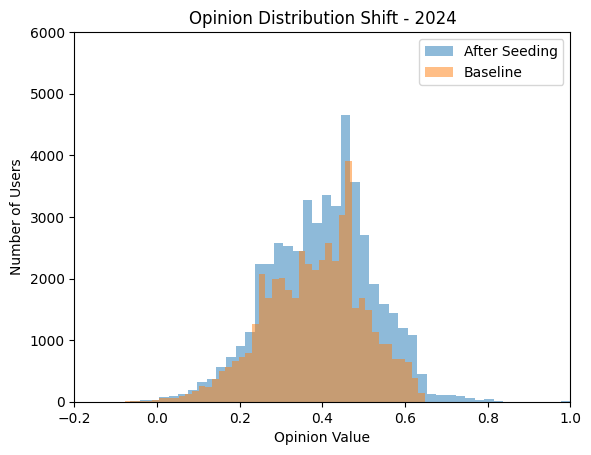

Loading graph...


In [23]:

base_dir = "fj_model_results"

years = []
scores = []
baselines = []
finals = []

for year in range(2018, 2025):
    file_path = os.path.join(base_dir, f"{year}_results.pickle")
    
    with open(file_path, "rb") as f:
        results = pickle.load(f)
    years.append(year)
    scores.append(np.mean(results["scores"]))       # aggregate per year
    baselines.append(np.mean(results["x_baseline"]))
    finals.append(np.mean(results["x_final"]))

    plot_distribution_shift(results["x_baseline"], results["x_final"], year)
    G, nodes = load_graph_and_matrices(f'network_graphs/network_graph_fj_{year}.pickle')
    plot_choropleth(G, nodes, results["x_baseline"], results["x_final"], year)
    
    
years = np.array(years)
scores = np.array(scores)
baselines = np.array(baselines)
finals = np.array(finals)

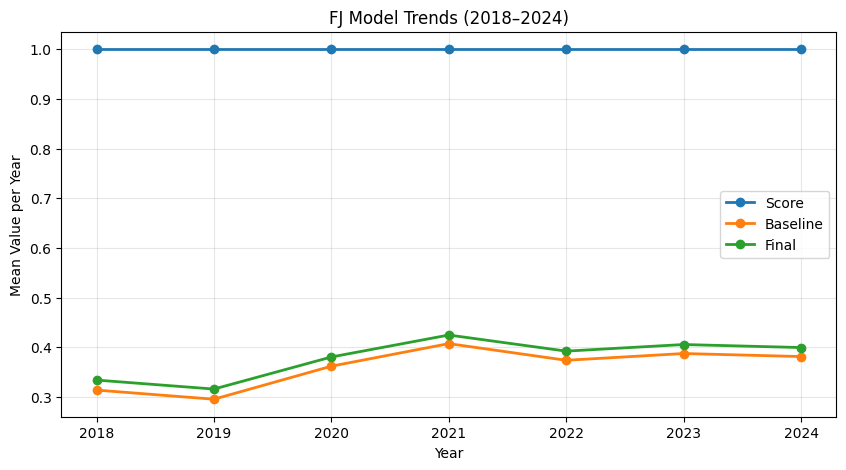

In [4]:
plt.figure(figsize=(10, 5))

plt.plot(years, scores, marker='o', linewidth=2, label='Score')
plt.plot(years, baselines, marker='o', linewidth=2, label='Baseline')
plt.plot(years, finals, marker='o', linewidth=2, label='Final')

plt.title("FJ Model Trends (2018–2024)")
plt.xlabel("Year")
plt.ylabel("Mean Value per Year")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

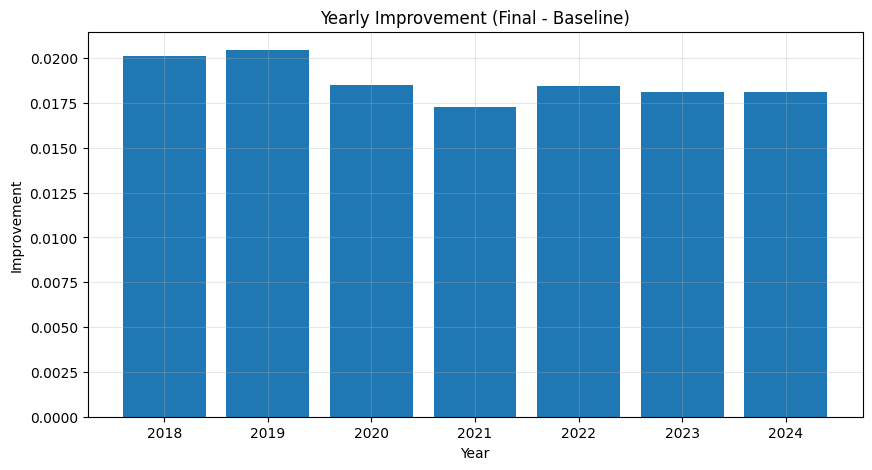

In [5]:
improvement = finals - baselines

plt.figure(figsize=(10, 5))

plt.bar(years, improvement)

plt.title("Yearly Improvement (Final - Baseline)")
plt.xlabel("Year")
plt.ylabel("Improvement")
plt.grid(True, alpha=0.3)
plt.show()

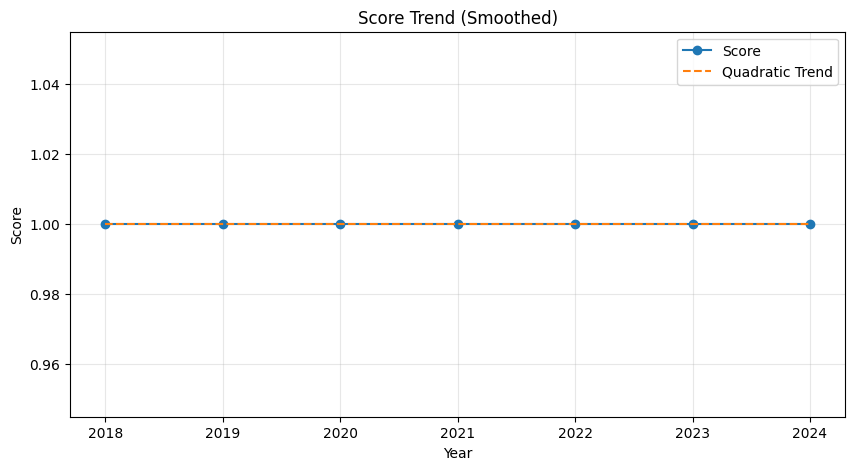

In [6]:
z = np.polyfit(years, scores, 2)
trend = np.poly1d(z)(years)

plt.figure(figsize=(10, 5))
plt.plot(years, scores, marker='o', label='Score')
plt.plot(years, trend, linestyle='--', label='Quadratic Trend')

plt.title("Score Trend (Smoothed)")
plt.xlabel("Year")
plt.ylabel("Score")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()